In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

# 데이터 로드
orders = pd.read_csv('/content/drive/MyDrive/취업 포폴/Olist 비즈니스 데이터 분석/olist data/olist_orders_dataset.csv')
customers = pd.read_csv('/content/drive/MyDrive/취업 포폴/Olist 비즈니스 데이터 분석/olist data/olist_customers_dataset.csv')

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 날짜 변환
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

# delivered만 사용
orders = orders[orders['order_status'] == 'delivered']

# 고객 unique id 붙이기
orders = orders.merge(
    customers[['customer_id', 'customer_unique_id']],
    on='customer_id'
)

In [27]:
orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6
...,...,...,...,...,...,...,...,...,...
96473,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00,6359f309b166b0196dbf7ad2ac62bb5a
96474,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,da62f9e57a76d978d02ab5362c509660
96475,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,737520a9aad80b3fbbdad19b66b37b30
96476,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,5097a5312c8b157bb7be58ae360ef43c


In [4]:
orders['customer_unique_id'].duplicated().sum()

np.int64(3120)

# Cohort - retention 분석

In [5]:
#월 단위 컬럼 생성
orders['order_quarter'] = orders['order_purchase_timestamp'].dt.to_period('Q')

In [6]:
# 고객별 첫 구매월
first_order = orders.groupby('customer_unique_id')['order_quarter'].min()

orders = orders.merge(
    first_order.rename('cohort_quarter'),
    on='customer_unique_id'
)

In [7]:
# Cohort Index (몇 개월 뒤인지)
orders['cohort_index'] = (
    (orders['order_quarter'].dt.year - orders['cohort_quarter'].dt.year) * 4 +
    (orders['order_quarter'].dt.quarter - orders['cohort_quarter'].dt.quarter)
)

In [8]:
cohort_data = orders.groupby(
    ['cohort_quarter', 'cohort_index']
)['customer_unique_id'].nunique().reset_index()
cohort_data

,cohort_quarter,cohort_index,customer_unique_id
0,2016Q3,0,1
1,2016Q4,0,263
2,2016Q4,1,1
3,2016Q4,2,1
4,2016Q4,3,2
5,2016Q4,4,1
6,2016Q4,5,2
7,2016Q4,6,4
8,2017Q1,0,4848
9,2017Q1,1,48


In [9]:
#Pivot
cohort_pivot = cohort_data.pivot(
    index='cohort_quarter',
    columns='cohort_index',
    values='customer_unique_id'
)

In [12]:
retention = cohort_pivot.divide(cohort_pivot[0], axis=0)
retention = retention.drop(columns=0)

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


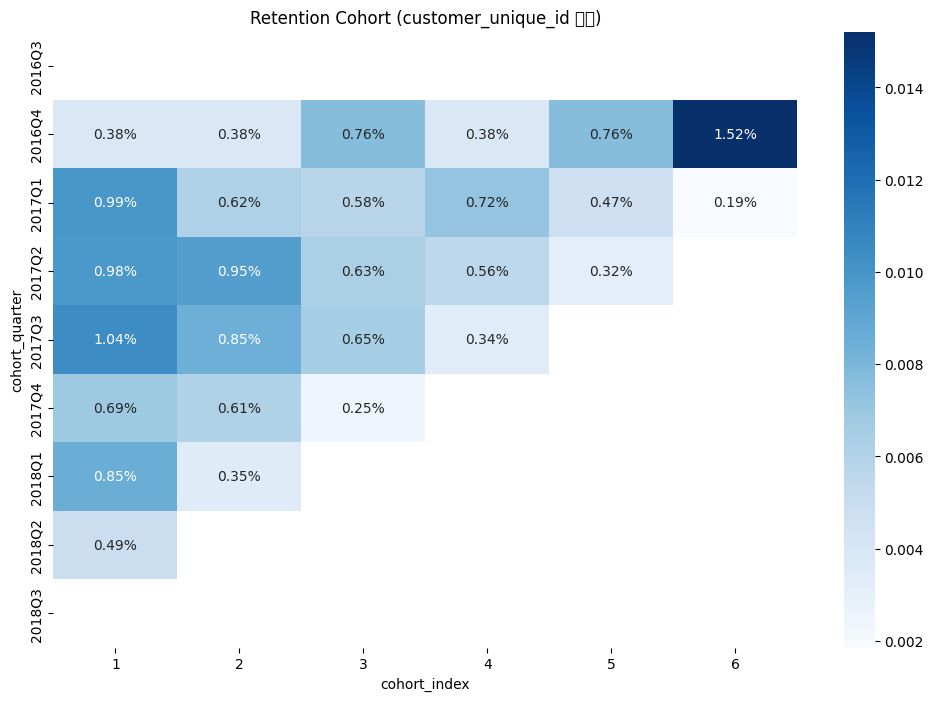

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(retention, annot=True, fmt=".2%", cmap='Blues')
plt.title('Retention Cohort (customer_unique_id 기준)')
plt.show()

### EDA

In [37]:
orders.groupby(['cohort_month', 'customer_unique_id']).size().reset_index(name='order_count')

dup_customers = orders.groupby(['cohort_month', 'customer_unique_id']).size().reset_index(name='order_count')

# 2번 이상 구매한 고객
dup_customers[dup_customers['order_count'] > 1]

,cohort_month,customer_unique_id,order_count
11,2016-10,0b3dc7efaafb0cf78a4796d42fa8d74c,2
14,2016-10,0ecf7f65b5ff3b9e61b637e59f495e0a,2
31,2016-10,1f98e3467d2b48dfb44fc12b137d3447,2
56,2016-10,32ea3bdedab835c3aa6cb68ce66565ef,3
84,2016-10,4962136f755981b83b03f476e66eea7d,2
...,...,...,...
92024,2018-08,c8460e4251689ba205045f3ea17884a1,4
92185,2018-08,cf56ccfd32ac8a510501a6fa69972c74,2
92361,2018-08,d649357bd5b1b116bf9662f41259db37,2
92752,2018-08,e6f7ddad5d0159e391e27db652c17246,2


In [39]:
dup = orders.groupby(['cohort_month', 'customer_unique_id']).size().reset_index(name='order_count')

dup_count = dup[dup['order_count'] > 1].groupby('cohort_month')['customer_unique_id'].count()
dup_count

,customer_unique_id
cohort_month,
2016-10,12
2016-12,1
2017-01,52
2017-02,66
2017-03,121
2017-04,102
2017-05,182
2017-06,161
2017-07,175


In [41]:
# 전체 고객 수
total = orders.groupby('cohort_month')['customer_unique_id'].nunique()

# 재구매 고객 수
repeat = dup[dup['order_count'] > 1].groupby('cohort_month')['customer_unique_id'].nunique()

# 비율
repeat_rate = (repeat / total).fillna(0)
repeat_rate

,customer_unique_id
cohort_month,
2016-09,0.000000
2016-10,0.045802
2016-12,1.000000
2017-01,0.072524
2017-02,0.040541
2017-03,0.048342
2017-04,0.045213
2017-05,0.052738
2017-06,0.053013


In [42]:
order_count = orders.groupby('customer_unique_id').size().reset_index(name='order_count')

repeat_customers = order_count[order_count['order_count'] > 1]
repeat_customers

,customer_unique_id,order_count
104,004288347e5e88a27ded2bb23747066c,2
243,00a39521eb40f7012db50455bf083460,2
305,00cc12a6d8b578b8ebd21ea4e2ae8b27,2
404,011575986092c30523ecb71ff10cb473,2
419,011b4adcd54683b480c4d841250a987f,2
...,...,...
92991,ff03923ad1eb9e32304deb7f9b2a45c9,2
93085,ff44401d0d8f5b9c54a47374eb48c1b8,2
93187,ff8892f7c26aa0446da53d01b18df463,2
93205,ff922bdd6bafcdf99cb90d7f39cea5b3,3


In [43]:
repeat_customers.sort_values(by='order_count', ascending=False).head(10)

,customer_unique_id,order_count
51431,8d50f5eadf50201ccdcedfb9e2ac8455,15
22779,3e43e6105506432c953e165fb2acf44c,9
73921,ca77025e7201e3b30c44b472ff346268,7
10060,1b6c7548a2a1f9037c1fd3ddfed95f33,7
36706,6469f99c1f9dfae7733b25662e7f1782,7
36500,63cfc61cee11cbe306bff5857d00bfe4,6
6964,12f5d6e1cbf93dafd9dcc19095df0b3d,6
26257,47c1a3033b8b77b3ab6e109eb4d5fdf3,6
87885,f0e310a6839dce9de1638e0fe5ab282a,6
80538,dc813062e0fc23409cd255f7f53c7074,6


In [49]:
segmented = repeat_customers.copy()

segmented['segment'] = pd.cut(
    segmented['order_count'],
    bins=[1, 3, 6, segmented['order_count'].max()],
    labels=['2-3회', '4-6회', '7회 이상']
)

segment_counts = segmented['segment'].value_counts().reset_index()
segment_counts.columns = ['segment', 'customer_count']
segment_counts

,segment,customer_count
0,2-3회,2754
1,4-6회,42
2,7회 이상,5


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


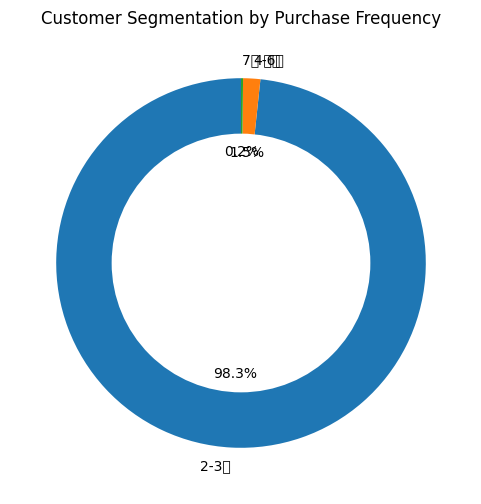

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.pie(
    segment_counts['customer_count'],
    labels=segment_counts['segment'],
    autopct='%1.1f%%',
    startangle=90
)

centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Customer Segmentation by Purchase Frequency')
plt.show()